✓ Environment checks passed
✓ Bitcoin data loaded (7,579,860 rows)
✓ Resampled to 5,266 daily observations
✓ Training observations: 5246

Class distribution:
Target
1    2788
0    2458
Name: count, dtype: int64

Train: 4196
Test : 1050

Running CV...

Logistic Regression CV: 49.45%
Random Forest CV: 49.59%

⏳ Tuning Random Forest...
✓ Tuning complete
{'forest_clf__n_estimators': 300, 'forest_clf__min_samples_split': 40, 'forest_clf__min_samples_leaf': 15, 'forest_clf__max_samples': 0.75, 'forest_clf__max_features': 0.4, 'forest_clf__max_depth': 5, 'forest_clf__class_weight': {0: 1, 1: 2.0}}
✓ Optimal threshold: 0.60


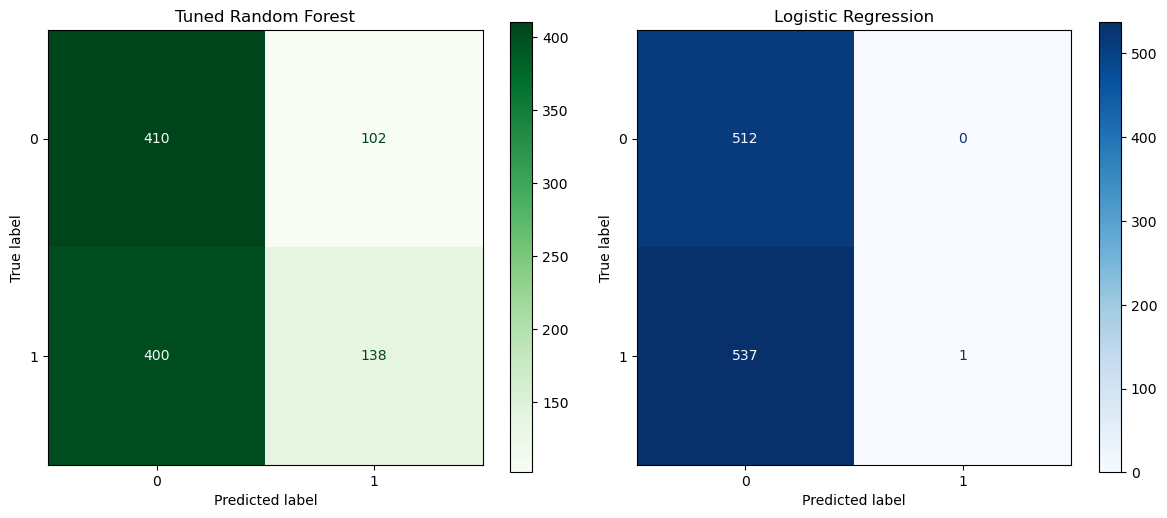

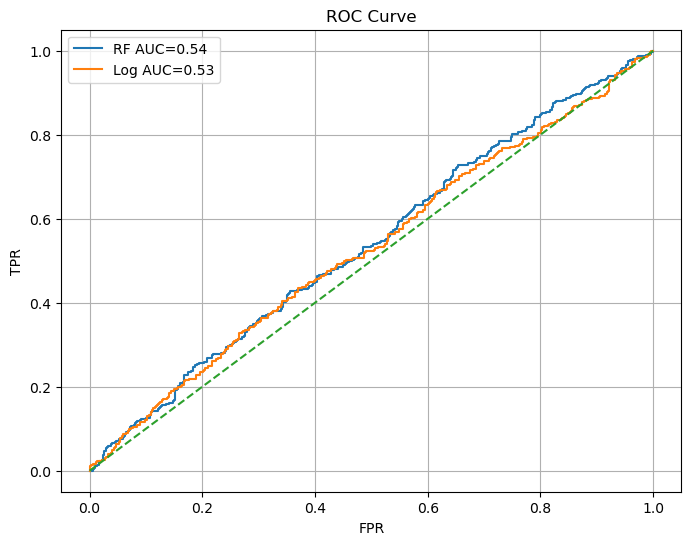

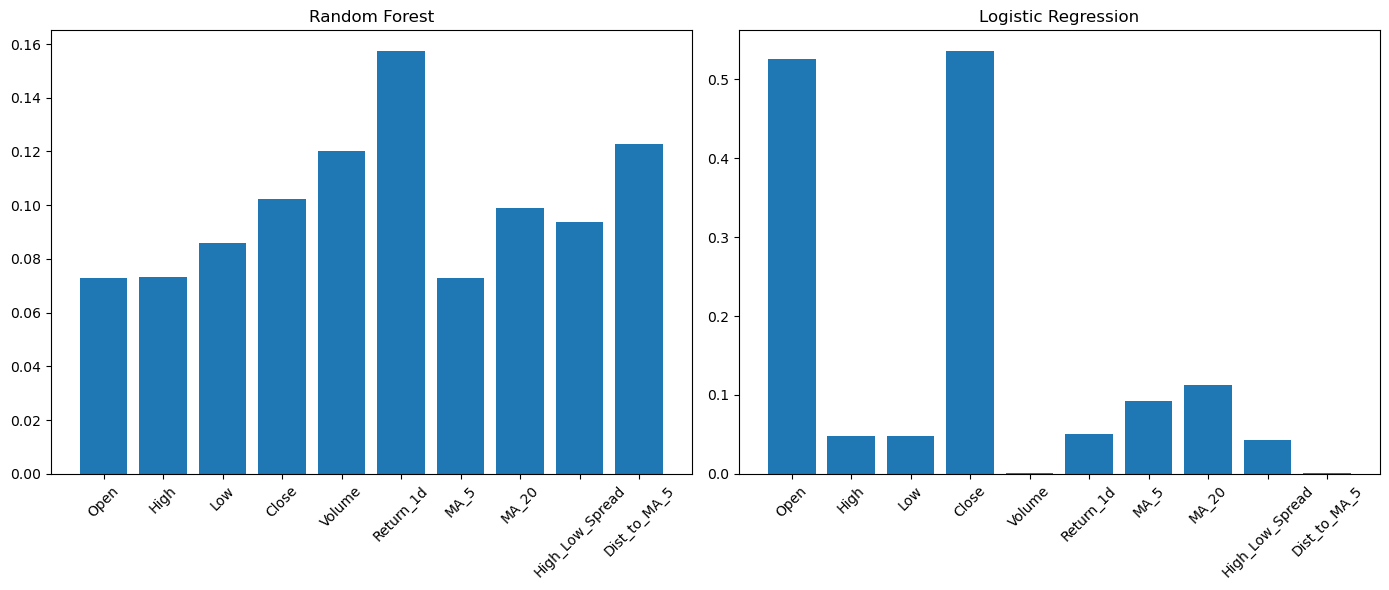


Random Forest Accuracy: 52.19%
Logistic Regression Accuracy: 48.86%

Random Forest Report:
              precision    recall  f1-score   support

           0       0.51      0.80      0.62       512
           1       0.57      0.26      0.35       538

    accuracy                           0.52      1050
   macro avg       0.54      0.53      0.49      1050
weighted avg       0.54      0.52      0.48      1050



In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from packaging import version

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    TimeSeriesSplit,
    cross_val_score,
    RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)

# ============================================================
# 2. ENVIRONMENT CHECKS
# ============================================================

MIN_PYTHON = (3, 7)
MIN_SKLEARN = "1.0.1"

if sys.version_info < MIN_PYTHON:
    raise RuntimeError(
        f"Python {MIN_PYTHON[0]}.{MIN_PYTHON[1]}+ required."
    )

if version.parse(sklearn.__version__) < version.parse(MIN_SKLEARN):
    raise RuntimeError(
        f"Scikit-learn {MIN_SKLEARN}+ required."
    )

print("✓ Environment checks passed")

# ============================================================
# 3. LOAD DATA
# ============================================================

DATA_PATH = Path("btcusd_1-min_data_2.csv")


def load_bitcoin_data(path=DATA_PATH):

    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found: {path.resolve()}"
        )

    df = pd.read_csv(path)

    print(f"✓ Bitcoin data loaded ({df.shape[0]:,} rows)")
    return df


bitcoin = load_bitcoin_data()

# ============================================================
# 4. INITIAL DATA PREP
# ============================================================

bitcoin["Datetime"] = pd.to_datetime(
    bitcoin["Timestamp"],
    unit="s"
)

bitcoin = (
    bitcoin
    .set_index("Datetime")
    .drop(columns="Timestamp")
)

# ============================================================
# 5. RESAMPLE TO DAILY DATA
# ============================================================

df_daily = pd.DataFrame({
    "Open": bitcoin["Open"].resample("D").first(),
    "High": bitcoin["High"].resample("D").max(),
    "Low": bitcoin["Low"].resample("D").min(),
    "Close": bitcoin["Close"].resample("D").last(),
    "Volume": bitcoin["Volume"].resample("D").sum(),
})

df_daily.dropna(inplace=True)

print(
    f"✓ Resampled to {df_daily.shape[0]:,} daily observations"
)

# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

df_daily["Next_Close"] = df_daily["Close"].shift(-1)

df_daily["Target"] = (
    df_daily["Next_Close"] > df_daily["Close"]
).astype(int)

df_daily["Return_1d"] = df_daily["Close"].pct_change()

df_daily["MA_5"] = (
    df_daily["Close"]
    .rolling(5)
    .mean()
)

df_daily["MA_20"] = (
    df_daily["Close"]
    .rolling(20)
    .mean()
)

df_daily["High_Low_Spread"] = (
    df_daily["High"] -
    df_daily["Low"]
)

df_daily["Dist_to_MA_5"] = (
    (df_daily["Close"] - df_daily["MA_5"])
    / df_daily["MA_5"]
)

df_daily.dropna(inplace=True)

feature_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return_1d",
    "MA_5",
    "MA_20",
    "High_Low_Spread",
    "Dist_to_MA_5",
]

X = df_daily[feature_cols]
y = df_daily["Target"]

print(f"✓ Training observations: {X.shape[0]}")

print("\nClass distribution:")
print(y.value_counts())

# ============================================================
# 7. CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(
    f"\nTrain: {X_train.shape[0]}"
    f"\nTest : {X_test.shape[0]}"
)

# ============================================================
# 8. MODELS
# ============================================================

log_reg = LogisticRegression(
    max_iter=2000
)

forest_clf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=7,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", log_reg),
])

pipe_forest = Pipeline([
    ("scaler", StandardScaler()),
    ("forest_clf", forest_clf),
])

# ============================================================
# 9. TIME SERIES CROSS-VALIDATION
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)

print("\nRunning CV...")

log_scores = cross_val_score(
    pipe_log,
    X,
    y,
    cv=tscv,
    scoring="accuracy"
)

forest_scores = cross_val_score(
    pipe_forest,
    X,
    y,
    cv=tscv,
    scoring="accuracy"
)

print(
    f"\nLogistic Regression CV:"
    f" {log_scores.mean()*100:.2f}%"
)

print(
    f"Random Forest CV:"
    f" {forest_scores.mean()*100:.2f}%"
)

# ============================================================
# 10. RANDOM FOREST TUNING
# ============================================================

print("\n⏳ Tuning Random Forest...")

param_distributions = {
    "forest_clf__n_estimators": [300, 700, 1200],
    "forest_clf__max_depth": [5, 8, 12, None],
    "forest_clf__min_samples_leaf": [1, 3, 7, 15],
    "forest_clf__min_samples_split": [5, 10, 20, 40],
    "forest_clf__max_features": [
        "sqrt",
        "log2",
        0.4,
        0.6
    ],
    "forest_clf__class_weight": [
        "balanced",
        {0: 1, 1: 1.2},
        {0: 1, 1: 1.5},
        {0: 1, 1: 2.0},
    ],
    "forest_clf__max_samples": [
        0.6,
        0.75,
        1.0
    ],
}

random_search = RandomizedSearchCV(
    estimator=pipe_forest,
    param_distributions=param_distributions,
    n_iter=100,
    cv=tscv,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

pipe_forest = random_search.best_estimator_

print("✓ Tuning complete")
print(random_search.best_params_)

# ============================================================
# 11. TRAIN FINAL MODELS
# ============================================================

pipe_log.fit(X_train, y_train)

y_probs_forest = (
    pipe_forest.predict_proba(X_test)[:, 1]
)

y_probs_log = (
    pipe_log.predict_proba(X_test)[:, 1]
)

# Optimize threshold

train_probs = (
    pipe_forest.predict_proba(X_train)[:, 1]
)

thresholds = np.arange(0.30, 0.65, 0.05)

f1_scores = [
    classification_report(
        y_train,
        (train_probs >= t).astype(int),
        output_dict=True,
        zero_division=0
    )["1"]["f1-score"]
    for t in thresholds
]

custom_threshold = thresholds[
    np.argmax(f1_scores)
]

print(
    f"✓ Optimal threshold:"
    f" {custom_threshold:.2f}"
)

y_pred_forest = (
    y_probs_forest >= custom_threshold
).astype(int)

y_pred_log = (
    y_probs_log >= custom_threshold
).astype(int)

# ============================================================
# 12. CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_forest,
    cmap="Greens",
    ax=axes[0]
)

axes[0].set_title(
    "Tuned Random Forest"
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_title(
    "Logistic Regression"
)

plt.tight_layout()
plt.show()

# ============================================================
# 13. ROC CURVE
# ============================================================

fpr_forest, tpr_forest, _ = roc_curve(
    y_test,
    y_probs_forest
)

auc_forest = roc_auc_score(
    y_test,
    y_probs_forest
)

fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_probs_log
)

auc_log = roc_auc_score(
    y_test,
    y_probs_log
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_forest,
    tpr_forest,
    label=f"RF AUC={auc_forest:.2f}"
)

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Log AUC={auc_log:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

# ============================================================
# 14. FEATURE IMPORTANCE
# ============================================================

rf_importance = (
    pipe_forest.named_steps["forest_clf"]
    .feature_importances_
)

log_importance = np.abs(
    pipe_log.named_steps["log_reg"]
    .coef_[0]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

axes[0].bar(
    feature_cols,
    rf_importance
)
axes[0].set_title(
    "Random Forest"
)
axes[0].tick_params(
    axis="x",
    rotation=45
)

axes[1].bar(
    feature_cols,
    log_importance
)
axes[1].set_title(
    "Logistic Regression"
)
axes[1].tick_params(
    axis="x",
    rotation=45
)

plt.tight_layout()
plt.show()

# ============================================================
# 15. FINAL REPORT
# ============================================================

acc_forest = accuracy_score(
    y_test,
    y_pred_forest
)

acc_log = accuracy_score(
    y_test,
    y_pred_log
)

print(
    f"\nRandom Forest Accuracy:"
    f" {acc_forest*100:.2f}%"
)

print(
    f"Logistic Regression Accuracy:"
    f" {acc_log*100:.2f}%"
)

print("\nRandom Forest Report:")
print(
    classification_report(
        y_test,
        y_pred_forest,
        zero_division=0
    )
)

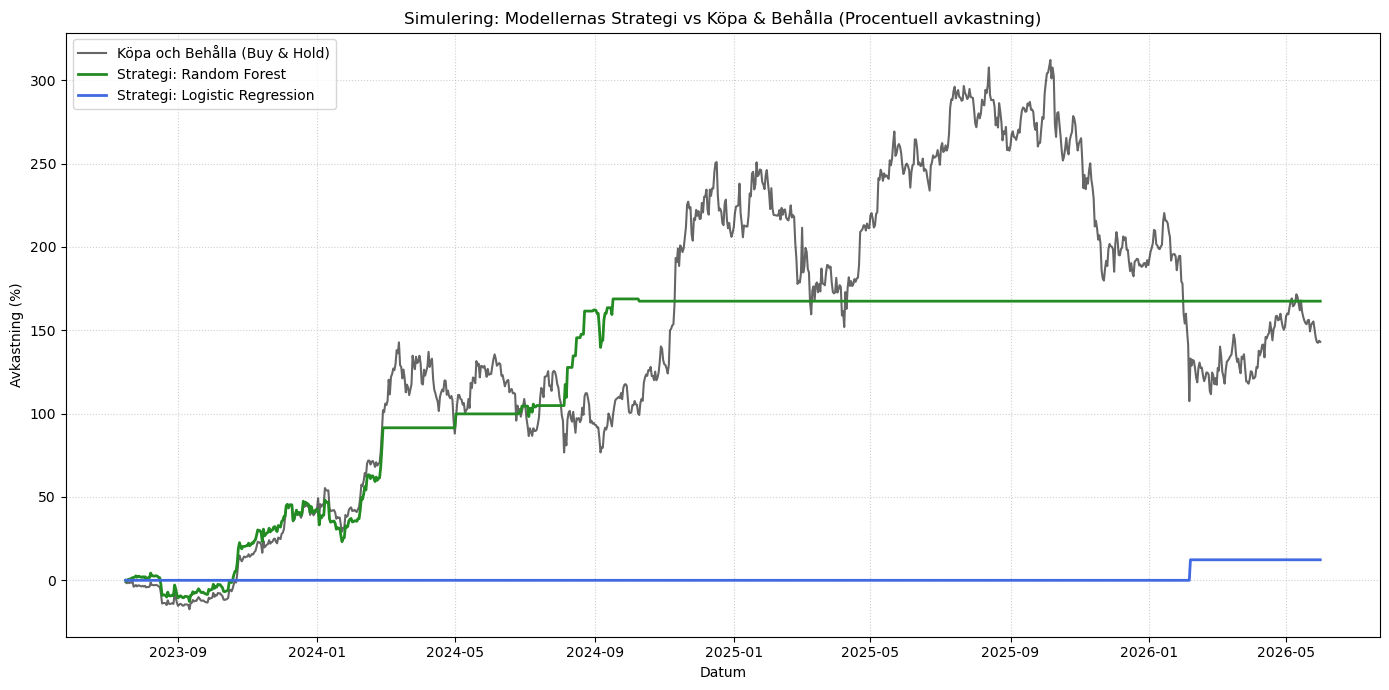

In [129]:
# ==========================================
# 9. STRATEGISIMULERING (Båda modeller vs Buy & Hold)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt

# 1. Skapa en kopia av test-datan för att räkna ut avkastning
strategy_df = pd.DataFrame(index=y_test.index)
strategy_df['Market_Return'] = X_test['Return_1d']

# 2. Hämta prediktionerna (signalerna) från BÅDA modellerna från tidigare steg
strategy_df['Signal_Forest'] = y_pred_forest
strategy_df['Signal_Log'] = y_pred_log

# 3. Om modellen gissar 1 får vi marknadens avkastning nästa dag. 
# Vi skiftar signalen med 1 eftersom vi agerar på signalen inför NÄSTA dag.
strategy_df['Return_Forest'] = strategy_df['Market_Return'] * strategy_df['Signal_Forest'].shift(1)
strategy_df['Return_Log'] = strategy_df['Market_Return'] * strategy_df['Signal_Log'].shift(1)

# Fyll i första raden som annars blir NaN på grund av shift(1)
strategy_df.fillna(0, inplace=True)

# 4. Beräkna kumulativ avkastning (procentuell utveckling över tid)
cum_market = (1 + strategy_df['Market_Return']).cumprod() - 1
cum_forest = (1 + strategy_df['Return_Forest']).cumprod() - 1
cum_log = (1 + strategy_df['Return_Log']).cumprod() - 1

# 5. Plotta resultatet
plt.figure(figsize=(14, 7))

# Svart streckad linje för marknaden (Buy & Hold)
plt.plot(cum_market.index, cum_market * 100, label='Köpa och Behålla (Buy & Hold)', color='black', alpha=0.6, linestyle='-')

# Grön linje för Random Forest
plt.plot(cum_forest.index, cum_forest * 100, label='Strategi: Random Forest', color='forestgreen', linewidth=2)

# Blå linje för Logistisk Regression
plt.plot(cum_log.index, cum_log * 100, label='Strategi: Logistic Regression', color='royalblue', linewidth=2)

# Inställningar för grafen
plt.title('Simulering: Modellernas Strategi vs Köpa & Behålla (Procentuell avkastning)')
plt.xlabel('Datum')
plt.ylabel('Avkastning (%)')
plt.legend(loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

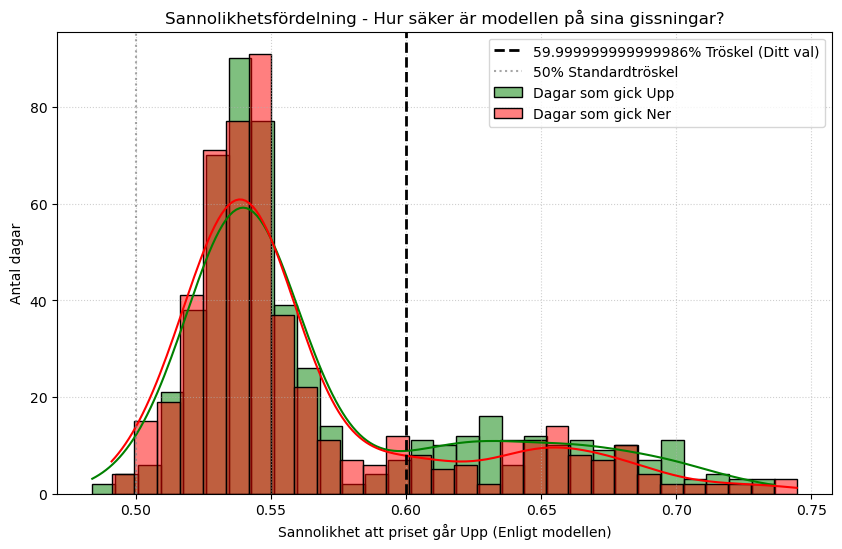

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

# RÄTTAD RAD: Vi lägger till .values här så att StandardScaler slipper varna
y_probs = pipe_forest.predict_proba(X_test.values)[:, 1]

plt.figure(figsize=(10, 6))

# Plotta vad modellen gissade när det FAKTISKT gick upp (grönt)
sns.histplot(y_probs[y_test == 1], bins=30, color='green', alpha=0.5, label='Dagar som gick Upp', kde=True)

# Plotta vad modellen gissade när det FAKTISKT gick ner (rött)
sns.histplot(y_probs[y_test == 0], bins=30, color='red', alpha=0.5, label='Dagar som gick Ner', kde=True)

plt.axvline(custom_threshold, color='black', linestyle='--', linewidth=2, label=f'{custom_threshold*100}% Tröskel (Ditt val)')
plt.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='50% Standardtröskel')

plt.title('Sannolikhetsfördelning - Hur säker är modellen på sina gissningar?')
plt.xlabel('Sannolikhet att priset går Upp (Enligt modellen)')
plt.ylabel('Antal dagar')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [132]:
import pandas as pd

# 1. Bygg om dagsdatan (utan att ta bort sista dagen)
df_latest = pd.DataFrame()
df_latest['Open'] = bitcoin['Open'].resample('D').first()
df_latest['High'] = bitcoin['High'].resample('D').max()
df_latest['Low'] = bitcoin['Low'].resample('D').min()
df_latest['Close'] = bitcoin['Close'].resample('D').last()
df_latest['Volume'] = bitcoin['Volume'].resample('D').sum()

# 2. Skapa dina features (EXAKT de 10 som modellen är tränad på nu)
df_latest['Return_1d'] = df_latest['Close'].pct_change()
df_latest['MA_5'] = df_latest['Close'].rolling(window=5).mean()
df_latest['MA_20'] = df_latest['Close'].rolling(window=20).mean()
df_latest['High_Low_Spread'] = df_latest['High'] - df_latest['Low']
df_latest['Dist_to_MA_5'] = (df_latest['Close'] - df_latest['MA_5']) / df_latest['MA_5']

# Se till att listan med features matchar perfekt
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume', 
    'Return_1d', 'MA_5', 'MA_20', 
    'High_Low_Spread', 'Dist_to_MA_5'
]

# 3. Plocka ut den ALLRA SISTA dagen i historiken
last_day_data = df_latest[feature_cols].iloc[-1:]

# Skriv ut vilket datum modellen gissar utifrån
print(f"Modellen analyserar data från: {last_day_data.index[0].strftime('%Y-%m-%d')}")
print(f"Stängningspris den dagen: {last_day_data['Close'].values[0]:.2f} USD\n")

# 4. Hämta sannolikheterna från vår tränade PIPELINE (med .values för att slippa varningar)
probabilities = pipe_forest.predict_proba(last_day_data.values)
prob_up = probabilities[0][1] # Sannolikheten för att priset går UPP

# 5. Sätt ditt anpassade tröskelvärde från trading-strategin
custom_threshold = 0.5

# 6. Räkna ut prediktionen baserat på ditt tröskelvärde
if prob_up >= custom_threshold:
    final_prediction = 1
else:
    final_prediction = 0

# 7. Skriv ut det spännande resultatet!
print("🔮 --- STRATEGISK PREDIKTION FÖR NÄSTA DAG --- 🔮")
print(f"Modellens beräknade chans för uppgång: {prob_up * 100:.1f}%")
print(f"Din valda aktiveringsgräns (Threshold): {custom_threshold * 100:.1f}%\n")

if final_prediction == 1:
    print("UPP/KÖP  (Modellens säkerhet räcker för att köpa!)")
else:
    print("NER eller STILLA/SÄLJ (Modellen är för osäker, sitt i kontanter!)")

Modellen analyserar data från: 2026-06-01
Stängningspris den dagen: 73633.40 USD

🔮 --- STRATEGISK PREDIKTION FÖR NÄSTA DAG --- 🔮
Modellens beräknade chans för uppgång: 54.0%
Din valda aktiveringsgräns (Threshold): 50.0%

UPP/KÖP  (Modellens säkerhet räcker för att köpa!)


⏳ Startar automatisk tuning av Random Forest (detta kan ta en minut eller två)...


C:\Users\nomis\miniconda3\envs\project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\nomis\miniconda3\envs\project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


✅ TUNING KLAR!
Bästa parametrarna:
{'forest_clf__n_estimators': 300, 'forest_clf__min_samples_split': 40, 'forest_clf__min_samples_leaf': 15, 'forest_clf__max_samples': 0.75, 'forest_clf__max_features': 0.4, 'forest_clf__max_depth': 5, 'forest_clf__class_weight': {0: 1, 1: 2.0}}
📐 Optimalt tröskelvärde: 0.60
------------------------------------------------------------


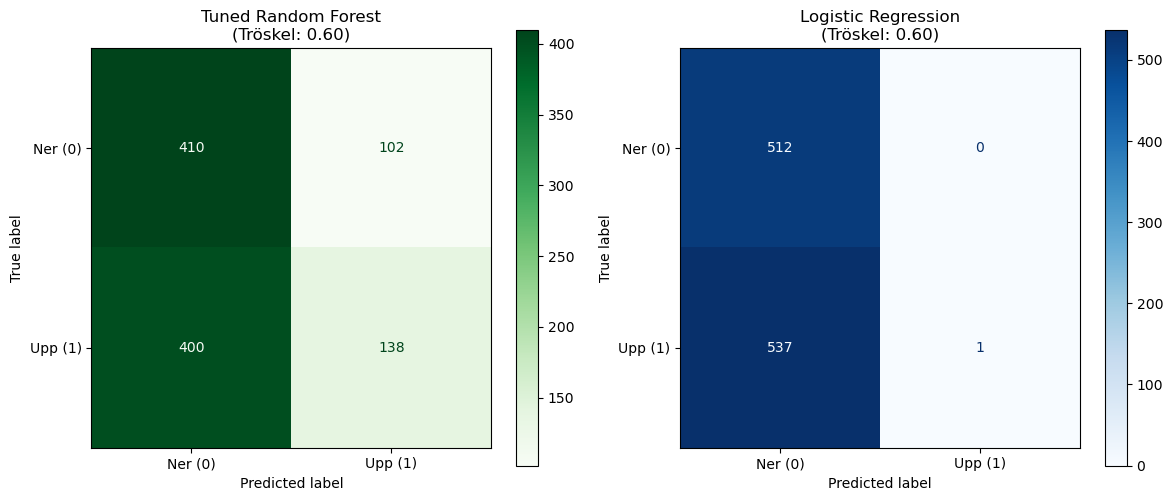

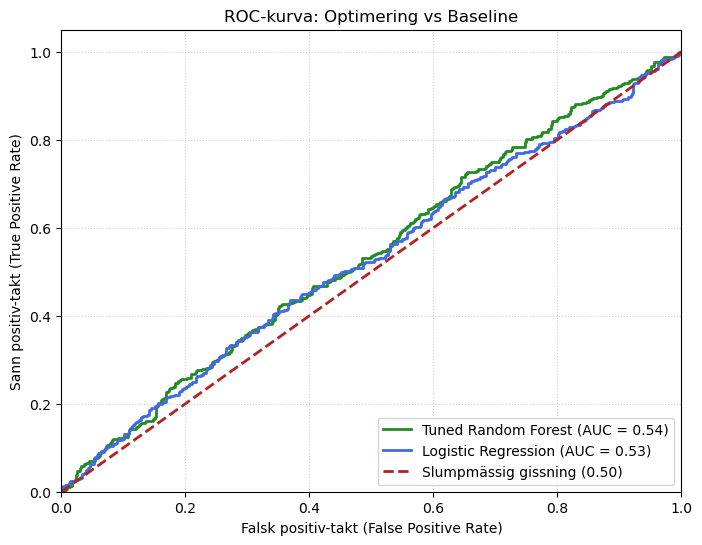

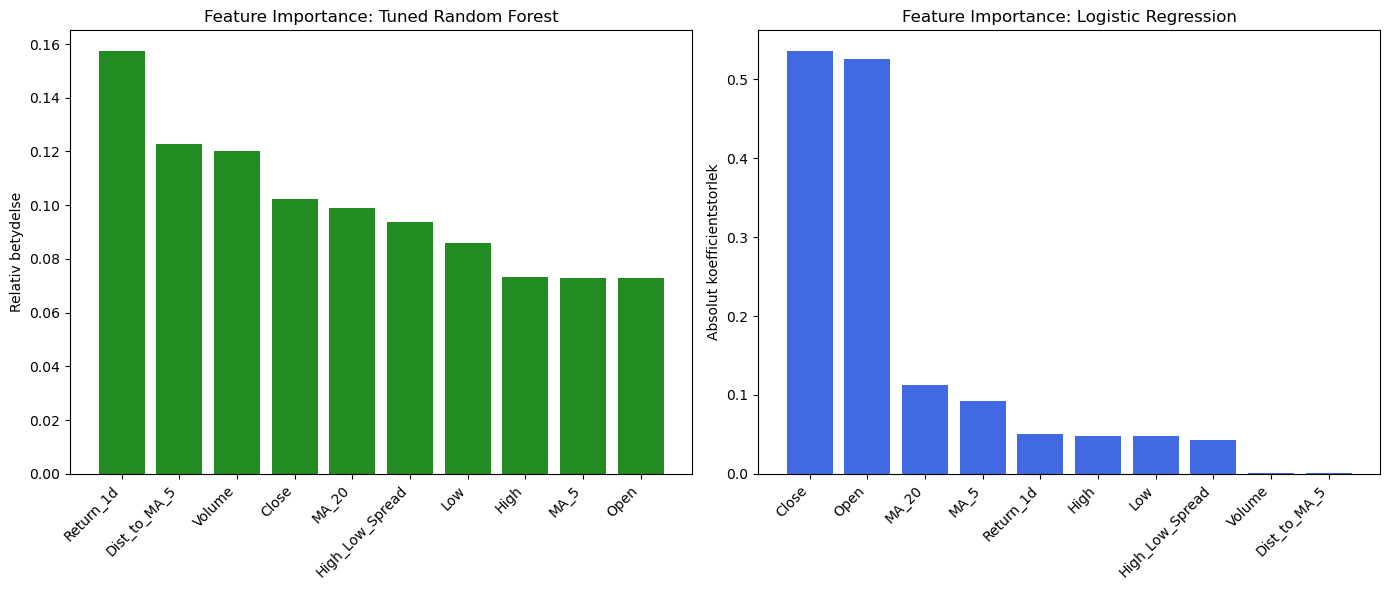

🎯 Tuned Random Forest Accuracy: 52.19%
🎯 Logistic Regression Accuracy: 48.86%

--- DETALJERAD RAPPORT: Tuned Random Forest ---
              precision    recall  f1-score   support

     Ner (0)       0.51      0.80      0.62       512
     Upp (1)       0.57      0.26      0.35       538

    accuracy                           0.52      1050
   macro avg       0.54      0.53      0.49      1050
weighted avg       0.54      0.52      0.48      1050


📊 Prediktionsfördelning (testset):
0    810
1    240
Name: count, dtype: int64
   Verklig fördelning: {1: 538, 0: 512}


In [128]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# ==========================================
# 1. AUTOMATISK TUNING AV RANDOM FOREST
# ==========================================
print("⏳ Startar automatisk tuning av Random Forest (detta kan ta en minut eller två)...")

param_distributions = {
    'forest_clf__n_estimators': [300, 700, 1200],
    'forest_clf__max_depth': [5, 8, 12, None],
    'forest_clf__min_samples_leaf': [1, 3, 7, 15],
    'forest_clf__min_samples_split': [5, 10, 20, 40],
    'forest_clf__max_features': ['sqrt', 'log2', 0.4, 0.6],
    'forest_clf__class_weight': [
        'balanced',
        {0: 1, 1: 1.2},
        {0: 1, 1: 1.5},
        {0: 1, 1: 2.0}
    ],
    'forest_clf__max_samples': [0.6, 0.75, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=pipe_forest, 
    param_distributions=param_distributions,
    n_iter=150,          
    cv=tscv,            
    scoring='f1', 
    random_state=42,
    n_jobs=-1           
)

# Träna sökningen
random_search.fit(X_train.values, y_train)

# Find the best threshold on the training set probabilities
y_probs_train = pipe_forest.predict_proba(X_train.values)[:, 1]
thresholds = np.arange(0.30, 0.65, 0.05)
f1_scores = [f1_score(y_train, (y_probs_train >= t).astype(int), zero_division=0) for t in thresholds]
custom_threshold = thresholds[np.argmax(f1_scores)]

print(f"✅ TUNING KLAR!")
print(f"Bästa parametrarna:\n{random_search.best_params_}")
print(f"📐 Optimalt tröskelvärde: {custom_threshold:.2f}")
print("-" * 60)

# ==========================================
# 2. UPPDATERA MODELL OCH PREDIKTIONER
# ==========================================
# Ersätt den gamla modellen med den nya vinnaren!
pipe_forest = random_search.best_estimator_

# Hämta exakta sannolikheter (Logistisk Regression finns redan tränad i minnet)
y_probs_forest = pipe_forest.predict_proba(X_test.values)[:, 1]
y_probs_log = pipe_log.predict_proba(X_test.values)[:, 1]

# Applicera tröskelvärdet
y_pred_forest = (y_probs_forest >= custom_threshold).astype(int)
y_pred_log = (y_probs_log >= custom_threshold).astype(int)

# ==========================================
# 3. RITA UPP ALLA GRAFER MED NYA MODELLEN
# ==========================================

# -- A. FÖRVIRRINGSMATRISER --
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_forest = confusion_matrix(y_test, y_pred_forest)
disp_forest = ConfusionMatrixDisplay(confusion_matrix=cm_forest, display_labels=['Ner (0)', 'Upp (1)'])
disp_forest.plot(cmap='Greens', ax=axes[0])
axes[0].set_title(f'Tuned Random Forest\n(Tröskel: {custom_threshold:.2f})')

cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Ner (0)', 'Upp (1)'])
disp_log.plot(cmap='Blues', ax=axes[1])
axes[1].set_title(f'Logistic Regression\n(Tröskel: {custom_threshold:.2f})')
plt.tight_layout()
plt.show()

# -- B. ROC KURVA --
fpr_forest, tpr_forest, _ = roc_curve(y_test, y_probs_forest)
auc_forest = roc_auc_score(y_test, y_probs_forest)
fpr_log, tpr_log, _ = roc_curve(y_test, y_probs_log)
auc_log = roc_auc_score(y_test, y_probs_log)

plt.figure(figsize=(8, 6))
plt.plot(fpr_forest, tpr_forest, color='forestgreen', lw=2, label=f'Tuned Random Forest (AUC = {auc_forest:.2f})')
plt.plot(fpr_log, tpr_log, color='royalblue', lw=2, label=f'Logistic Regression (AUC = {auc_log:.2f})')
plt.plot([0, 1], [0, 1], color='firebrick', lw=2, linestyle='--', label='Slumpmässig gissning (0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Falsk positiv-takt (False Positive Rate)')
plt.ylabel('Sann positiv-takt (True Positive Rate)')
plt.title('ROC-kurva: Optimering vs Baseline')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# -- C. FEATURE IMPORTANCE --
importances_rf = pipe_forest.named_steps['forest_clf'].feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]
sorted_features_rf = [feature_cols[i] for i in indices_rf]

importances_log = np.abs(pipe_log.named_steps['log_reg'].coef_[0])
indices_log = np.argsort(importances_log)[::-1]
sorted_features_log = [feature_cols[i] for i in indices_log]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].bar(range(X.shape[1]), importances_rf[indices_rf], color='forestgreen', align='center')
axes[0].set_xticks(range(X.shape[1]))
axes[0].set_xticklabels(sorted_features_rf, rotation=45, ha='right')
axes[0].set_title('Feature Importance: Tuned Random Forest')
axes[0].set_ylabel('Relativ betydelse')

axes[1].bar(range(X.shape[1]), importances_log[indices_log], color='royalblue', align='center')
axes[1].set_xticks(range(X.shape[1]))
axes[1].set_xticklabels(sorted_features_log, rotation=45, ha='right')
axes[1].set_title('Feature Importance: Logistic Regression')
axes[1].set_ylabel('Absolut koefficientstorlek')
plt.tight_layout()
plt.show()

# ==========================================
# 4. ACCURACY RAPPORT
# ==========================================
acc_forest = accuracy_score(y_test, y_pred_forest)
acc_log = accuracy_score(y_test, y_pred_log)

print(f"🎯 Tuned Random Forest Accuracy: {acc_forest * 100:.2f}%")
print(f"🎯 Logistic Regression Accuracy: {acc_log * 100:.2f}%\n")

print("--- DETALJERAD RAPPORT: Tuned Random Forest ---")
print(classification_report(y_test, y_pred_forest, target_names=['Ner (0)', 'Upp (1)'], zero_division=0))

print("\n📊 Prediktionsfördelning (testset):")
print(pd.Series(y_pred_forest).value_counts())
print(f"   Verklig fördelning: {pd.Series(y_test).value_counts().to_dict()}")

